# Does the churn signal hold for brand-new phrases? (Frame-N confirmation, demo)

This notebook demonstrates **experiment 13** of the *concepts spread once adopters make them* project. It is a sealed confirmation with a single unseal. The question is whether the **home-neighbourhood openness / novelty signal** (`OPEN_home`, `NOVCHURN_home`) anticipates a concept's *later disciplinary breadth*. Earlier experiments (EXP8 → EXP10) found this signal for legacy OpenAlex/MAG concepts. This experiment tests it on a second, vocabulary-free population, **Frame N**.

**Frame N** = newborn title noun phrases, with onsets from 2003 to 2015. These phrases are absent both from the 56,643 legacy OpenAlex/MAG concepts and from the 65,026 `art_O7Dq4L02QnDN` labels. Mining, counting and LLM gating left **636 concepts**. For each concept:

* **Early indices** (t0−3 … t0+2) are built from the concept's co-author ego network inside its home field: `OPEN_home` (churn/openness) and `NOVCHURN_home` (novelty-weighted churn).
* **Outcome** is later venue-field breadth, `O2r_m30`, measured in the window t0+6 … t0+8. It became the primary outcome under declared fallback A.
* **Score** is the partial Spearman correlation (**psp**) between index and outcome. It controls for a *ladder* of covariate rungs, R0 (the B5 volume/growth/reach/entropy/off-home-share baseline plus onset-year dummies) through R5 (plus home-group fixed effects). Each cell gets a 95% concept-bootstrap CI.

**Frozen verdict: PARTIAL.** On the full frame, `OPEN_home` psp is +0.117 [+0.020, +0.218] at R3 and +0.086 [−0.009, +0.190] at R5.

**About the original script.** The artifact's `method.py` is a *stage driver*. It runs 10 resumable stages (S0 pre-registration → S9 audit), each as a subprocess. Those stages need the 2026-09-23 OpenAlex S3 snapshot, which takes about 20 minutes of range reads, plus OpenRouter LLM calls, so they cannot run in Colab. This notebook therefore:
1. runs the original driver **verbatim in its default plan-only mode**, which prints the stage plan;
2. runs the **original S8 scoring code** (`psp_point`, `psp_boot2`, `rung_design`, `per_group`, copied verbatim from the artifact's `lib/`) on a stratified 100-concept subset of the sealed analysis frame;
3. compares the demo psp values with the frozen full-sample cells from the single unseal.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# loguru — NOT pre-installed on Colab, always install
_pip('loguru==0.7.3')

# numpy, pandas, scipy, matplotlib — pre-installed on Colab, install locally only (Colab's exact versions)
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'scipy==1.16.3', 'matplotlib==3.10.0')

## Imports
The first block is the original `method.py` import block, unchanged. The second block adds what the scoring library (`lib/rq1stats.py`, `lib/ladder.py`, `lib/laddern.py`) and the visualisation need.

In [2]:
from __future__ import annotations

import argparse
import os
import subprocess
import sys
import time
from pathlib import Path

from loguru import logger

# --- additional imports: S8 scoring library (lib/rq1stats.py, lib/ladder.py, lib/laddern.py) + notebook plots
import json
import math

import numpy as np
import pandas as pd
from scipy import stats
from scipy.stats import rankdata
import matplotlib.pyplot as plt

## Load the demo data
`mini_demo_data.json` holds 100 Frame-N concepts, sampled at random within each analysis group (seed 0). They come from the 448 concepts with a finite `OPEN_home` and `O2r_m30` in the sealed `data/analysis_frame_n.parquet`. For each concept the file stores:
* the phrase, which is the `input`;
* the rung-ladder covariates;
* the early ego-network indices;
* the outcomes.

The file's `metadata` also carries the **frozen full-sample psp cells** (B = 2000, seed 20260929), used for comparison.

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-papers/ai-invention-8795ea-concepts-spread-once-adopters-make-them/fork/run_hy6I3YyVxPEP/round-5/experiment-13/demo/mini_demo_data.json"
import json
from pathlib import Path

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    local = Path("mini_demo_data.json")
    if local.exists(): return json.loads(local.read_text())
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(data["metadata"]["description"])
print("examples:", len(data["datasets"][0]["examples"]), "| primary outcome:", data["metadata"]["primary_outcome"],
      "| frozen verdict:", data["metadata"]["verdict"])

Frame-N demo subset: 100 newborn title-phrase concepts (stratified by analysis group, seed 0) drawn from the 448 concepts with finite OPEN_home and O2r_m30 in data/analysis_frame_n.parquet. input = phrase; output = observed O2r_m30 (later venue-field breadth). metadata_* = rung-ladder covariates, early ego-network indices and outcomes. frozen_full_sample_cells = the psp cells of the single unseal on the full frame (B = 2000, seed 20260929).
examples: 100 | primary outcome: O2r_m30 | frozen verdict: PARTIAL


## Configuration
Every tunable parameter is set here. The demo values are small so the notebook runs in about a minute. The original values are given in the comments.

In [5]:
# --- driver (method.py) ---
START_STAGE = "S0"          # original default: --from S0
END_STAGE = "S9"            # original default: --to S9
RUN_STAGES = False          # original default: plan only (--run executes; needs the S3 snapshot + OpenRouter -> not in Colab)

# --- S8 scoring (lib/scoring.py cells_for / s8_unseal.py) ---
N_CONCEPTS = 100           # original: all 636 Frame-N concepts (448 with finite OPEN_home & O2r_m30); demo file has 100
N_BOOT = 2000              # original: B = 2000 concept-bootstrap resamples (1000 for per-group cells)
SEED = 20260929             # original bootstrap seed (unchanged)
PRIM = data["metadata"]["primary_outcome"]      # "O2r_m30" (declared fallback A)
INDICES = ["OPEN_home", "NOVCHURN_home"]        # original: ["OPEN_home", "OPEN_all", "OPEN_sizematch", "NOVCHURN_home"]
OUTCOMES = [PRIM, "O2r_m50"]                    # original: (prim, "O2r_resid", "O2r_m50")
RUNGS_TO_SCORE = ["R0", "R1", "R2", "R3", "R4", "R5"]   # original: all six rungs
PER_GROUP_RUNG = "R0"       # original: "R3" (with 100 demo concepts a group has only 30-42 rows -> R3 design is saturated, every resample NaN)
PER_GROUP_N_BOOT = min(1000, N_BOOT)   # original: min(1000, B)

## The original stage driver (`method.py`)
`STAGES` lists every pipeline step in order:

| Stage | What it does |
|---|---|
| S0 | pre-registration seal |
| S1 | unit tests |
| S2 | Pass M: mining a 20% file sample |
| S3 | candidate phrases |
| S4 | Pass N: full-corpus counts 1995–2022, with outcome rows sealed at write time |
| S5 | masked onset rule, then the LLM precision gate (M1) and the categorical gate (G2) |
| S6 | ego-network features, B5 baselines, Cheng et al. consistency |
| S7 | power analysis and freeze |
| S8 | **the single unseal and frozen scoring** |
| S9 | independent audit and outputs |

Only `ROOT` changes. It now points to the notebook's working directory, because a notebook has no `__file__`.

In [6]:
ROOT = Path.cwd()   # original: Path(__file__).resolve().parent  (a notebook has no __file__)
PY = str(ROOT / ".venv" / "bin" / "python")
STAGES = [
    ("S0", [["s0_prereg.py"]]),
    ("S1", [["tests/unit_tests_port.py"], ["tests/unit_tests_new.py"]]),
    ("S2", [["passM.py", "--workers", "9"], ["passM.py", "--merge", "--workers", "6"]]),
    ("S3", [["s3_candidates.py", "--stage", "all"]]),
    ("S4", [["passN.py", "--workers", "9"], ["passN.py", "--merge"]]),
    ("S5", [["s5_onset.py"], ["s5_gate.py", "estimate"], ["s5_gate.py", "run"], ["s5_gate.py", "m2", "--m2all"],
            ["s5_gate.py", "sheet"], ["s5_gate.py", "score"], ["s5_gate.py", "m2rest"], ["s5_gate.py", "sheet2"],
            ["s5_gate2.py", "eval"], ["s5_gate2.py", "run"], ["s5_gate2.py", "frame"]]),
    ("S6", [["s6_features.py", "--workers", "9"]]),
    ("S7", [["s7_freeze.py", "prepare"], ["s7_freeze.py", "power"], ["s8_unseal.py", "--dryrun"],
            ["s7_freeze.py", "freeze"]]),
    ("S8", [["s8_unseal.py"]]),
    ("S9", [["audit_frame_n.py"], ["make_outputs_n.py"]]),
]

`main()` is the original driver. There is one minimal change: it takes an `argv` list instead of reading the notebook kernel's command line. Without `--run` it only logs the plan, which is the original default behaviour.

In [7]:
@logger.catch(reraise=True)
def main(argv: list[str] | None = None) -> None:
    ap = argparse.ArgumentParser()
    ap.add_argument("--from", dest="start", default="S0")
    ap.add_argument("--to", dest="end", default="S9")
    ap.add_argument("--run", action="store_true")
    a = ap.parse_args(argv)   # original: ap.parse_args()  (notebook: explicit argv)
    logger.remove()
    logger.add(sys.stdout, level="INFO", format="{time:HH:mm:ss}|{level:<7}|{message}")
    (ROOT / "logs").mkdir(exist_ok=True)
    logger.add(ROOT / "logs" / "method.log", rotation="30 MB", level="DEBUG")
    names = [s for s, _ in STAGES]
    todo = STAGES[names.index(a.start):names.index(a.end) + 1]
    env = dict(os.environ, PYTHONPATH=str(ROOT / "lib"), OMP_NUM_THREADS="1", OPENBLAS_NUM_THREADS="1",
               MKL_NUM_THREADS="1")
    for stage, cmds in todo:
        for c in cmds:
            logger.info(f"{stage}: {' '.join(c)}")
            if not a.run:
                continue
            t = time.time()
            r = subprocess.run([PY, *c], cwd=ROOT, env=env)
            if r.returncode != 0:
                logger.error(f"{stage} failed ({' '.join(c)}), exit {r.returncode}")
                raise SystemExit(r.returncode)
            logger.info(f"{stage} ok in {(time.time() - t) / 60:.1f} min")


main(["--from", START_STAGE, "--to", END_STAGE] + (["--run"] if RUN_STAGES else []))

02:15:28|INFO   |S0: s0_prereg.py


02:15:28|INFO   |S1: tests/unit_tests_port.py


02:15:28|INFO   |S1: tests/unit_tests_new.py


02:15:28|INFO   |S2: passM.py --workers 9


02:15:28|INFO   |S2: passM.py --merge --workers 6


...

02:15:28|INFO   |S7: s8_unseal.py --dryrun


02:15:28|INFO   |S7: s7_freeze.py freeze


02:15:28|INFO   |S8: s8_unseal.py


02:15:28|INFO   |S9: audit_frame_n.py


02:15:28|INFO   |S9: make_outputs_n.py


## S8 scoring core: partial Spearman with a refit concept bootstrap
These functions are copied **verbatim** from the artifact's library. They are what `s8_unseal.py` calls, through `lib/scoring.py`, at the single unseal.

* `psp_point`: rank-transform x, y and the B5 baseline. Residualise both ranks on the baseline ranks plus the categorical dummies. Return the Pearson correlation of the two residuals.
* `psp_boot2`: point estimate plus a concept bootstrap. The rank residualisation is refit in every resample. Returns the percentile CI, the SE and a one-sided p in the frozen direction.
* `dersimonian_laird`: random-effects pooling across analysis groups.

In [8]:
# ---------------- lib/rq1stats.py (verbatim)
def _resid(Z: np.ndarray, Y: np.ndarray) -> np.ndarray:
    beta, *_ = np.linalg.lstsq(Z, Y, rcond=None)
    return Y - Z @ beta


def psp_point(x: np.ndarray, y: np.ndarray, B: np.ndarray, cat: np.ndarray | None) -> float:
    """Pearson(resid(rank x ~ rank B + cat dummies), resid(rank y ~ same)). Rows must be complete."""
    Zc = [np.ones((len(x), 1))]
    if B is not None and B.shape[1]:
        Zc.append(rankdata(B, axis=0))
    if cat is not None and cat.shape[1]:
        Zc.append(cat)
    Z = np.hstack(Zc)
    R = _resid(Z, np.c_[rankdata(x), rankdata(y)])
    sx, sy = R[:, 0].std(), R[:, 1].std()
    if sx <= 1e-12 or sy <= 1e-12:
        return float("nan")
    return float(np.corrcoef(R[:, 0], R[:, 1])[0, 1])


def dersimonian_laird(b, se) -> dict:
    """EXP6 lib/stats_core.dersimonian_laird (verbatim logic)."""
    b, se = np.asarray(b, float), np.asarray(se, float)
    ok = np.isfinite(b) & np.isfinite(se) & (se > 0)
    b, se = b[ok], se[ok]
    k = len(b)
    if k == 0:
        return {"k": 0, "b": float("nan"), "se": float("nan"), "ci": [float("nan")] * 2, "p": float("nan"),
                "tau2": float("nan"), "I2": float("nan"), "Q": float("nan")}
    w = 1 / se**2
    bf = (w * b).sum() / w.sum()
    Q = float((w * (b - bf) ** 2).sum())
    Cc = w.sum() - (w**2).sum() / w.sum()
    tau2 = max(0.0, (Q - (k - 1)) / Cc) if k > 1 and Cc > 0 else 0.0
    ws = 1 / (se**2 + tau2)
    bre = (ws * b).sum() / ws.sum()
    sre = math.sqrt(1 / ws.sum())
    I2 = max(0.0, (Q - (k - 1)) / Q) if Q > 0 and k > 1 else 0.0
    return {"k": k, "b": float(bre), "se": sre, "ci": [float(bre - 1.96 * sre), float(bre + 1.96 * sre)],
            "p": float(2 * stats.norm.sf(abs(bre / sre))), "tau2": float(tau2), "Q": Q, "I2": float(I2)}


# ---------------- lib/ladder.py (verbatim; EXP10 code)
def psp_boot2(x: np.ndarray, y: np.ndarray, B: np.ndarray, C: np.ndarray, n_boot: int, seed: int,
              direction: int = 1, idx_boot: np.ndarray | None = None) -> dict:
    ok = np.isfinite(x) & np.isfinite(y) & np.all(np.isfinite(B), 1) & np.all(np.isfinite(C), 1)
    x, y, B, C = x[ok], y[ok], B[ok], C[ok]
    n = len(x)
    if n < 30 or np.unique(x).size < 3:
        return {"n": int(n), "rho": math.nan, "ci": [math.nan, math.nan], "se": math.nan, "p_one": math.nan,
                "p_two": math.nan, "boot": np.array([])}
    est = psp_point(x, y, B, C)
    rng = np.random.default_rng(seed)
    bs = np.empty(n_boot)
    for b in range(n_boot):
        i = rng.integers(0, n, n)
        Ci = C[i]
        keep = Ci.std(0) > 0 if Ci.shape[1] else np.zeros(0, bool)
        bs[b] = psp_point(x[i], y[i], B[i], Ci[:, keep])
    bs = bs[np.isfinite(bs)]
    lo, hi = np.percentile(bs, [2.5, 97.5])
    p_one = float((np.sum(direction * bs <= 0) + 1) / (len(bs) + 1))
    z = np.arctanh(np.clip(bs, -0.999999, 0.999999))
    se_z = float(np.std(z, ddof=1))
    ze = math.atanh(max(min(est, 0.999999), -0.999999))
    return {"n": int(n), "rho": float(est), "ci": [float(lo), float(hi)], "se": float(np.std(bs, ddof=1)),
            "p_one": p_one, "p_two": float(2 * stats.norm.sf(abs(ze / se_z))) if se_z > 0 else math.nan,
            "boot": bs}

## The Frame-N covariate ladder (`lib/laddern.py`, verbatim)
Each rung adds controls, so a positive psp that survives to R3/R5 is not explained by size, reach, type, footprint, coverage or field:

| Rung | Covariates |
|---|---|
| R0 | B5 (ranked) plus onset-year dummies (reference year 2008), plus `window_flag` for the 2015 extension |
| R1 | R0 plus `CONTACT_REACH` |
| R2 | R1 plus type dummies and `generic` |
| R3 | R2 plus footprint (`fp_logN`, `fp_nfields`, `fp_reemerge`) |
| R4 | R3 plus label and home coverage |
| R5 | R4 plus home-group fixed effects |

Constant columns are dropped automatically.

In [9]:
B5 = ["logvol", "growth_c", "offhome_share", "entropy", "reach"]
RUNGS = ["R0", "R1", "R2", "R3", "R4", "R5"]
POOL_GROUPS = ["CS+Eng", "BGM+Med", "PHYS", "LIFEENV", "SOC"]
REF_YEAR = 2008


def year_dummies(df: pd.DataFrame) -> pd.DataFrame:
    ys = [y for y in sorted(df.t0.unique()) if y != REF_YEAR]
    return pd.DataFrame({f"t0_{y}": (df.t0 == y).astype(float) for y in ys}, index=df.index)


def type_dummies(df: pd.DataFrame) -> pd.DataFrame:
    t = df["type"].fillna("unlabelled")
    return pd.DataFrame({f"type_{c}": (t == c).astype(float) for c in ("method", "object", "property", "unlabelled")},
                        index=df.index)


def group_dummies(df: pd.DataFrame) -> pd.DataFrame:
    gs = [g for g in sorted(df.agroup.dropna().unique()) if g != "BGM+Med"]
    return pd.DataFrame({f"g_{g}": (df.agroup == g).astype(float) for g in gs}, index=df.index)


def rung_design(df: pd.DataFrame, rung: str, drop_type: bool = False, drop_group: bool = False,
                type_generic_only: bool = False) -> tuple[pd.DataFrame, pd.DataFrame]:
    r = RUNGS.index(rung)
    cont = list(B5)
    cat = [year_dummies(df)]
    if "window_flag" in df.columns and df.window_flag.nunique() > 1:
        cat.append(df[["window_flag"]].astype(float))
    if r >= 1:
        cont.append("CONTACT_REACH")
    if r >= 2:
        if not drop_type and not type_generic_only:
            cat.append(type_dummies(df))
        cat.append(df[["generic"]].astype(float))
    if r >= 3:
        cont += ["fp_logN", "fp_nfields"]
        if "fp_reemerge" in df.columns:          # D_fp_reemerge: not constant in Frame N (EXP10 R3 column)
            cat.append(df[["fp_reemerge"]].astype(float))
    if r >= 4:
        cont += ["label_coverage_early", "home_coverage_early"]
    if r >= 5 and not drop_group:
        cat.append(group_dummies(df))
    C = pd.concat(cat, axis=1) if cat else pd.DataFrame(index=df.index)
    C = C.loc[:, C.std() > 0] if len(C) > 1 else C
    Bc = df[cont]
    Bc = Bc.loc[:, Bc.std() > 0] if len(Bc) > 1 else Bc
    return Bc, C


def psp_df(df: pd.DataFrame, xcol: str, ycol: str, rung: str, n_boot: int, seed: int, direction: int = 1,
           keep_boot: bool = False, **kw) -> dict:
    Bc, Cc = rung_design(df, rung, **kw)
    r = psp_boot2(df[xcol].to_numpy(float), df[ycol].to_numpy(float), Bc.to_numpy(float), Cc.to_numpy(float),
                  n_boot, seed, direction)
    r.update({"x": xcol, "y": ycol, "rung": rung, "resampling_unit": "concept", "n_boot": n_boot})
    if not keep_boot:
        r.pop("boot", None)
    return r


def per_group(df: pd.DataFrame, xcol: str, ycol: str, rung: str, n_boot: int, seed: int, direction: int = 1) -> dict:
    rows = {}
    for gi, g in enumerate(POOL_GROUPS + ["MATHDEC"]):
        d = df[df.agroup == g]
        rows[g] = psp_df(d, xcol, ycol, rung, n_boot, seed + 101 * gi, direction, drop_group=True)
    est = [g for g in POOL_GROUPS if rows[g]["n"] >= 30 and np.isfinite(rows[g]["rho"])]
    b = [rows[g]["rho"] for g in est]
    se = [rows[g]["se"] for g in est]
    dl = dersimonian_laird(b, se) if len(est) >= 2 else {}
    logo = {}
    for g in est:
        o = [h for h in est if h != g]
        if len(o) >= 2:
            logo[g] = dersimonian_laird([rows[h]["rho"] for h in o], [rows[h]["se"] for h in o])
    pos = int(sum(1 for v in b if v > 0))
    return {"groups": rows, "estimable": est, "n_estimable": len(est), "DL": dl, "n_positive": pos,
            "leave_one_group_out": logo, "x": xcol, "y": ycol, "rung": rung}

## Build the analysis frame from the demo data
This cell replaces the original `pd.read_parquet(DATA / "analysis_features_frame_n.parquet")` merged with the unsealed outcomes. It turns the `metadata_*` fields back into columns and keeps the first `N_CONCEPTS` concepts.

In [10]:
rows = []
for e in data["datasets"][0]["examples"]:
    r = {k[len("metadata_"):]: v for k, v in e.items() if k.startswith("metadata_")}
    r["name"] = e["input"]
    rows.append(r)
df = pd.DataFrame(rows).head(N_CONCEPTS)
for c in df.columns:
    if c not in ("agroup", "type", "gloss", "name"):
        df[c] = pd.to_numeric(df[c], errors="coerce")
df["has_open_home"] = np.isfinite(df.OPEN_home)
print(df.shape)
print("by group:", df.agroup.value_counts().to_dict())
print("by onset year:", df.t0.value_counts().sort_index().to_dict())
df[["name", "t0", "agroup", "type", "logvol", "reach", "OPEN_home", "NOVCHURN_home", "O2r_m30", "gloss"]].head(8)

(100, 31)
by group: {'BGM+Med': 42, 'CS+Eng': 30, 'SOC': 12, 'PHYS': 11, 'LIFEENV': 3, 'MATHDEC': 2}
by onset year: {2003: 3, 2004: 9, 2005: 8, 2006: 11, 2007: 4, 2008: 8, 2009: 10, 2010: 5, 2011: 11, 2012: 6, 2013: 10, 2014: 5, 2015: 10}


,name,t0,agroup,type,logvol,reach,OPEN_home,NOVCHURN_home,O2r_m30,gloss
0,cell lymphoma patients,2007,BGM+Med,topic,4.127134,1,0.213288,-0.391240,3.060002,Patients diagnosed with cell lymphoma.
1,education exam,2006,BGM+Med,topic,4.709530,2,1.300679,0.879553,2.578947,Examinations related to continuing medical edu...
2,h5n1 virus,2006,BGM+Med,object,4.770685,5,0.559259,-0.287370,5.227772,A specific subtype of the avian influenza viru...
3,calr mutations,2014,BGM+Med,object,4.605170,1,0.074017,0.550899,1.769231,Mutations in the Calreticulin gene associated ...
4,endothelial keratoplasty,2006,BGM+Med,method,5.424950,2,-0.850975,-1.375938,1.546593,A surgical procedure to replace the inner laye...
5,ipv6 networks,2004,CS+Eng,topic,4.672829,3,0.195528,-0.148901,2.000000,Computer networks using the Internet Protocol ...
6,political civilization,2003,SOC,topic,6.196444,3,0.510559,0.019394,2.990808,The development and characteristics of politic...
7,steam program,2013,CS+Eng,topic,4.262680,2,0.291976,1.147369,3.363619,"An educational program integrating Science, Te..."


## Score the ladder cells (the first block of `lib/scoring.py::cells_for`)
For each index × outcome × rung, compute psp with the concept-bootstrap CI. The original runs these cells in a spawn process pool with B = 2000. Here they run sequentially with `N_BOOT` resamples, over the `INDICES` / `OUTCOMES` / `RUNGS_TO_SCORE` chosen in the config cell.

In [11]:
t = time.time()
cells = {}
for x in INDICES:
    for y in OUTCOMES:
        for r in RUNGS_TO_SCORE:
            cells[f"ladder|{x}|{y}|{r}"] = psp_df(df, xcol=x, ycol=y, rung=r, n_boot=N_BOOT, seed=SEED)
print(f"{len(cells)} cells in {time.time() - t:.1f} s")
for k, c in cells.items():
    print(f"{k:<35} n={c['n']:<4} psp={c['rho']:+.3f}  CI [{c['ci'][0]:+.3f}, {c['ci'][1]:+.3f}]  p_one={c['p_one']:.3f}")

24 cells in 18.3 s
ladder|OPEN_home|O2r_m30|R0         n=100  psp=+0.269  CI [+0.053, +0.478]  p_one=0.010
ladder|OPEN_home|O2r_m30|R1         n=100  psp=+0.280  CI [+0.075, +0.475]  p_one=0.004
ladder|OPEN_home|O2r_m30|R2         n=100  psp=+0.325  CI [+0.106, +0.532]  p_one=0.002
ladder|OPEN_home|O2r_m30|R3         n=100  psp=+0.321  CI [+0.094, +0.545]  p_one=0.004
ladder|OPEN_home|O2r_m30|R4         n=100  psp=+0.376  CI [+0.144, +0.585]  p_one=0.001
ladder|OPEN_home|O2r_m30|R5         n=100  psp=+0.367  CI [+0.133, +0.604]  p_one=0.003
ladder|OPEN_home|O2r_m50|R0         n=86   psp=+0.254  CI [+0.010, +0.485]  p_one=0.023
ladder|OPEN_home|O2r_m50|R1         n=86   psp=+0.260  CI [+0.023, +0.471]  p_one=0.016
ladder|OPEN_home|O2r_m50|R2         n=86   psp=+0.312  CI [+0.083, +0.547]  p_one=0.009
ladder|OPEN_home|O2r_m50|R3         n=86   psp=+0.316  CI [+0.061, +0.574]  p_one=0.012
ladder|OPEN_home|O2r_m50|R4         n=86   psp=+0.347  CI [+0.080, +0.589]  p_one=0.006
ladder|OPEN_h

## Per-group heterogeneity and DerSimonian–Laird pooling
The original scores `OPEN_home` separately inside each analysis group, then pools the estimable groups (n ≥ 30) with random effects. In the full frame, 3 of the 4 estimable groups are positive and the DL estimate is +0.112 [−0.015, +0.239]. In the demo only BGM+Med (42) and CS+Eng (30) reach n ≥ 30. With so few rows per group, the R3 design has almost as many columns as rows, and every bootstrap resample returns NaN. The demo therefore scores the groups at `PER_GROUP_RUNG = "R0"`, the B5 plus year baseline.

In [12]:
grp = per_group(df, "OPEN_home", PRIM, PER_GROUP_RUNG, PER_GROUP_N_BOOT, SEED)
for g, rr in grp["groups"].items():
    print(f"{g:<8} n={rr['n']:<4} psp={rr['rho']:+.3f}" if np.isfinite(rr["rho"]) else f"{g:<8} n={rr['n']:<4} (not estimable)")
print("estimable:", grp["estimable"], "| positive:", grp["n_positive"], "| DL:", {k: grp["DL"][k] for k in ("b", "ci")} if grp["DL"] else "n/a (<2 estimable groups)")

CS+Eng   n=30   psp=+0.219
BGM+Med  n=42   psp=+0.413
PHYS     n=11   (not estimable)
LIFEENV  n=3    (not estimable)
SOC      n=12   (not estimable)
MATHDEC  n=2    (not estimable)
estimable: ['CS+Eng', 'BGM+Med'] | positive: 2 | DL: {'b': 0.3776626152830026, 'ci': [-0.02084824973895255, 0.7761734803049578]}


## Results: demo subset vs. frozen full-sample unseal
The table puts each demo cell next to the frozen cell from the single unseal (full frame, B = 2000). The demo uses at most 100 concepts against 448 in the full frame, so its CIs are roughly twice as wide, and individual estimates can differ from the frozen ones. The comparison is about *direction*: a positive signal across the ladder. This particular 100-concept draw happens to give larger psp values than the full frame, which is ordinary small-sample variation. The frozen full-sample numbers are the confirmatory ones.

        index outcome rung  demo_n  demo_psp  demo_lo  demo_hi  full_n  full_psp  full_lo  full_hi
    OPEN_home O2r_m30   R0     100     0.269    0.053    0.478     448     0.157    0.063    0.253
    OPEN_home O2r_m30   R1     100     0.280    0.075    0.475     448     0.127    0.026    0.229
    OPEN_home O2r_m30   R2     100     0.325    0.106    0.532     448     0.126    0.024    0.227
    OPEN_home O2r_m30   R3     100     0.321    0.094    0.545     448     0.117    0.020    0.218
    OPEN_home O2r_m30   R4     100     0.376    0.144    0.585     448     0.107    0.011    0.211
    OPEN_home O2r_m30   R5     100     0.367    0.133    0.604     448     0.086   -0.009    0.190
    OPEN_home O2r_m50   R0      86     0.254    0.010    0.485     397     0.193    0.092    0.290
    OPEN_home O2r_m50   R1      86     0.260    0.023    0.471     397     0.162    0.066    0.262
    OPEN_home O2r_m50   R2      86     0.312    0.083    0.547     397     0.164    0.068    0.264
    OPEN_h

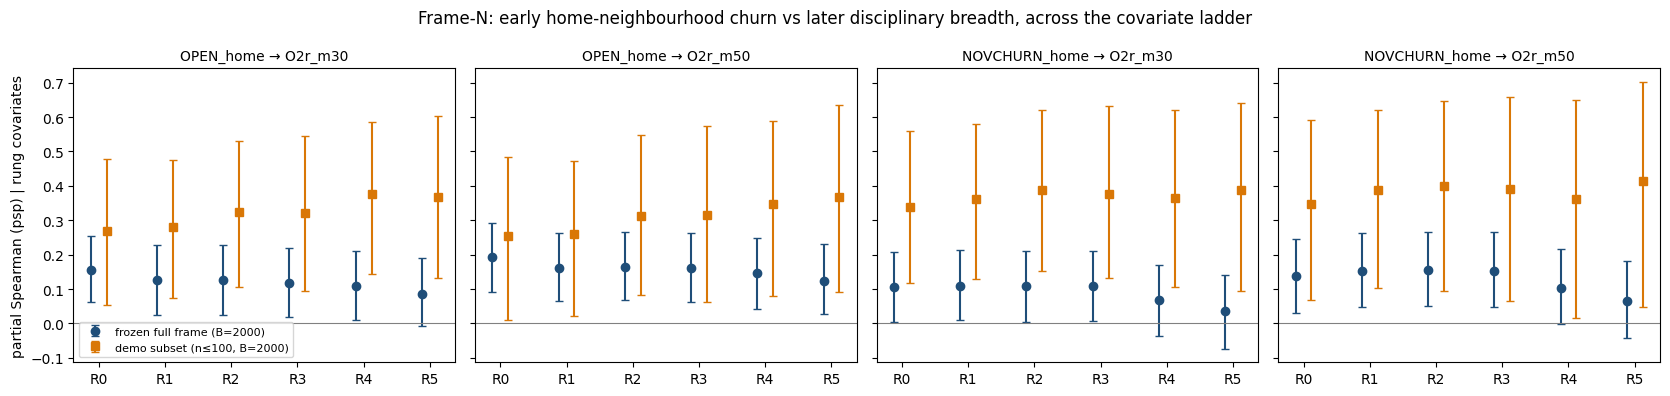

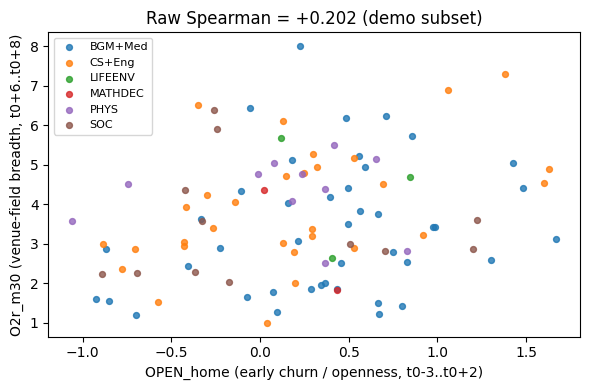

Frozen verdict (full frame): PARTIAL


In [13]:
frozen = data["metadata"]["frozen_full_sample_cells"]
tab = []
for k, c in cells.items():
    f = frozen.get(k, {})
    _, x, y, r = k.split("|")
    tab.append({"index": x, "outcome": y, "rung": r, "demo_n": c["n"], "demo_psp": c["rho"],
                "demo_lo": c["ci"][0], "demo_hi": c["ci"][1],
                "full_n": f.get("n"), "full_psp": f.get("rho"),
                "full_lo": (f.get("ci") or [np.nan, np.nan])[0], "full_hi": (f.get("ci") or [np.nan, np.nan])[1]})
tab = pd.DataFrame(tab)
pd.set_option("display.width", 160)
print(tab.round(3).to_string(index=False))

fig, axes = plt.subplots(1, len(INDICES) * len(OUTCOMES), figsize=(4.2 * len(INDICES) * len(OUTCOMES), 4), sharey=True)
axes = np.atleast_1d(axes)
for ax, ((x, y), d) in zip(axes, tab.groupby(["index", "outcome"], sort=False)):
    pos = np.arange(len(d))
    ax.errorbar(pos - 0.12, d.full_psp, yerr=[d.full_psp - d.full_lo, d.full_hi - d.full_psp], fmt="o",
                color="#1f4e79", capsize=3, label="frozen full frame (B=2000)")
    ax.errorbar(pos + 0.12, d.demo_psp, yerr=[d.demo_psp - d.demo_lo, d.demo_hi - d.demo_psp], fmt="s",
                color="#d97706", capsize=3, label=f"demo subset (n≤{N_CONCEPTS}, B={N_BOOT})")
    ax.axhline(0, color="grey", lw=0.8)
    ax.set_xticks(pos, d.rung)
    ax.set_title(f"{x} → {y}", fontsize=10)
axes[0].set_ylabel("partial Spearman (psp) | rung covariates")
axes[0].legend(fontsize=8, loc="lower left")
fig.suptitle("Frame-N: early home-neighbourhood churn vs later disciplinary breadth, across the covariate ladder")
plt.tight_layout()
plt.show()

# Raw relationship: OPEN_home vs later breadth, coloured by analysis group
fig, ax = plt.subplots(figsize=(6, 4))
for g, d in df.groupby("agroup"):
    ax.scatter(d.OPEN_home, d[PRIM], s=18, label=g, alpha=0.8)
ax.set_xlabel("OPEN_home (early churn / openness, t0-3..t0+2)")
ax.set_ylabel(f"{PRIM} (venue-field breadth, t0+6..t0+8)")
ax.legend(fontsize=8)
ax.set_title(f"Raw Spearman = {stats.spearmanr(df.OPEN_home, df[PRIM], nan_policy='omit')[0]:+.3f} (demo subset)")
plt.tight_layout()
plt.show()
print("Frozen verdict (full frame):", data["metadata"]["verdict"])